# Business Intelligence Workshop 

Authors:

- Juan Pablo Molina

- Ian Spikin

# W1\-A · Relevance and documentary foundation — 25 points

Somos de DataCO

Candidato A — Comportamiento de ventas por región:
“¿Cómo varían las categorías de productos más vendidas entre regiones y qué factores están asociados a un menor volumen de ventas?”

Se busca aumentar el volumen de ventas implementando una estrategia adecuada, ya sea potenciando productos comprados frecuentemente, o indagando en los productos menos vendidos, y si hay algún bloqueo en sus ventas, o si el mercado para ellos es más pequeño\. 

Candidato B — Eficiencia logística y tardanzas:
“¿Cómo varía el riesgo de entrega tardía entre regiones y categorías de productos, y qué factores operacionales están asociados a estas diferencias?”

Se busca detectar los productos con más entregas tardías y encontrar las regiones con problemas para tomar acciones en el momento \.

Fuente que usaremos para verificar y analizar los problemas:

https://data\.mendeley\.com/datasets/8gx2fvg2k6/5

Fuentes Bibliográficas:

What is the value of delivering on time?

https://www\.emerald\.com/jamr/article\-abstract/17/4/473/201694/What\-is\-the\-value\-of\-delivering\-on\-time?redirectedFrom=fulltext

The Effect of Delivery Time on Repurchase Behavior in Quick Commerce

https://www\.researchgate\.net/publication/384990655\_The\_Effect\_of\_Delivery\_Time\_on\_Repurchase\_Behavior\_in\_Quick\_Commerce

# W1\-B · Actual data inspection and initial understanding — 30 points

Core evidence: source\-specific inspection for both lines or a documented infeasibility finding for one; at least one
actual\-data summary with interpretation; identifiable observation units and coverage for the inspected data\.

Se revisa el dataset encontrado en la fuente mencionada en el punto A: DataCoSupplyChainDataset\.csv

Para facilitar el trabajo, se convierte a formato parquet, lo que guarda el DataFrame de forma más compacta, por lo que se lee e importa más rápidamente

El dataset DataCo Supply Chain contiene 180\.519 registros y 53 variables relacionadas con ventas, productos, clientes, pedidos y procesos logísticos\. Incluye información sobre categorías de productos, regiones, métodos de envío, tiempos reales y programados de entrega, estado de los pedidos y riesgo de atraso\. Esto permite analizar patrones de ventas y estudiar posibles factores asociados a las entregas tardías\.

In [1]:
import pandas as pd

Se corre una vez la conversión del CSV a parquet, utilizándolo para iniciar el dataset en el futuro\.

In [2]:
# df = pd.read_csv("/work/DataCoSupplyChainDataset.csv", encoding = "ISO-8859-1")
# df = df.convert_dtypes()
# df.to_parquet('data.parquet')
df = pd.read_parquet('data.parquet')

In [3]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,<NA>,1360,73,<NA>,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,<NA>,1360,73,<NA>,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,<NA>,1360,73,<NA>,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,<NA>,1360,73,<NA>,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,<NA>,1360,73,<NA>,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.0,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,<NA>,1004,45,<NA>,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,<NA>,1004,45,<NA>,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,<NA>,1004,45,<NA>,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,<NA>,1004,45,<NA>,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


Datos y sus caracterisiticas del dataset

In [4]:
# Dimensiones del dataset
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

# Tipos de datos
display(df.dtypes)

# Valores nulos
nulos = df.isnull().sum().sort_values(ascending=False)
display(nulos[nulos > 0])

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

Filas: 180519
Columnas: 53


Type                             string[python]
Days for shipping (real)                  Int64
Days for shipment (scheduled)             Int64
Benefit per order                       Float64
Sales per customer                      Float64
Delivery Status                  string[python]
Late_delivery_risk                        Int64
Category Id                               Int64
Category Name                    string[python]
Customer City                    string[python]
Customer Country                 string[python]
Customer Email                   string[python]
Customer Fname                   string[python]
Customer Id                               Int64
Customer Lname                   string[python]
Customer Password                string[python]
Customer Segment                 string[python]
Customer State                   string[python]
Customer Street                  string[python]
Customer Zipcode                          Int64
Department Id                           

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

Filas duplicadas: 0


Candidato A:                                                  
“¿Cómo varía el riesgo de entrega tardía entre regiones y categorías de productos, y qué factores operacionales están asociados a estas diferencias?”

Para responder la pregunta se utilizarán principalmente las siguientes variables del dataset:

Late\_delivery\_risk: indica si existe riesgo de entrega tardía\.
Order Region: región asociada al pedido\.
Category Name: categoría del producto\.
Shipping Mode: modalidad de envío\.
Days for shipping \(real\): días reales utilizados para el envío\.
Days for shipment \(scheduled\): días programados para el envío\.
Delivery Status: estado final de la entrega\.
Order Id: identificador del pedido\.
Order Item Id: identificador del producto dentro del pedido\.

In [6]:
columnas = [
    "Late_delivery_risk",
    "Order Region",
    "Category Name",
    "Shipping Mode",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df[columnas].head())
display(df[columnas].isnull().sum())

Filas: 180519
Columnas: 53


,Late_delivery_risk,Order Region,Category Name,Shipping Mode,Days for shipping (real),Days for shipment (scheduled)
0,0,Southeast Asia,Sporting Goods,Standard Class,3,4
1,1,South Asia,Sporting Goods,Standard Class,5,4
2,0,South Asia,Sporting Goods,Standard Class,4,4
3,0,Oceania,Sporting Goods,Standard Class,3,4
4,0,Oceania,Sporting Goods,Standard Class,2,4


Late_delivery_risk               0
Order Region                     0
Category Name                    0
Shipping Mode                    0
Days for shipping (real)         0
Days for shipment (scheduled)    0
dtype: int64

In [8]:
riesgo_region = (
    df.groupby("Order Region")["Late_delivery_risk"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

riesgo_region["mean"] *= 100

riesgo_region.columns = [
    "Riesgo de atraso (%)",
    "Cantidad de registros"
]

display(riesgo_region)

,Riesgo de atraso (%),Cantidad de registros
Order Region,,
Central Africa,57.960644,1677
South Asia,56.266977,7731
East Africa,55.939525,1852
Western Europe,55.848611,27109
South of USA,55.772559,4045
Eastern Europe,55.663265,3920
East of USA,55.661605,6915
Southeast Asia,55.52993,9539
Central Asia,55.334539,553


In [10]:
riesgo_envio = (
    df.groupby("Shipping Mode")["Late_delivery_risk"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

riesgo_envio["mean"] *= 100

display(riesgo_envio)

,mean,count
Shipping Mode,,
First Class,95.322499,27814
Second Class,76.632781,35216
Same Day,45.743042,9737
Standard Class,38.071683,107752


Los resultados permiten comparar si existen diferencias en la proporción de entregas con riesgo de atraso entre regiones y modalidades de envío\. Estas diferencias deben interpretarse inicialmente como asociaciones y no como relaciones causales, ya que otros factores, como la categoría del producto o los tiempos programados de envío, también podrían influir\.

Candidato B
“¿Cómo varía el riesgo de entrega tardía entre regiones y categorías de productos, y qué factores operacionales están asociados a estas diferencias?”

Para responder la pregunta se utilizarán principalmente las siguientes variables del dataset:

Late\_delivery\_risk: indica si una entrega presenta riesgo de atraso\.
Order Region: permite comparar el comportamiento de las entregas entre distintas regiones\.
Category Name: identifica la categoría del producto asociado al pedido\.
Shipping Mode: representa la modalidad de envío utilizada\.
Days for shipping \(real\): cantidad de días reales que tomó el envío\.
Days for shipment \(scheduled\): cantidad de días programados para realizar el envío\.

In [12]:
columnas = [
    "Late_delivery_risk",
    "Order Region",
    "Category Name",
    "Shipping Mode",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df[columnas].head())
display(df[columnas].isnull().sum())

Filas: 180519
Columnas: 53


,Late_delivery_risk,Order Region,Category Name,Shipping Mode,Days for shipping (real),Days for shipment (scheduled)
0,0,Southeast Asia,Sporting Goods,Standard Class,3,4
1,1,South Asia,Sporting Goods,Standard Class,5,4
2,0,South Asia,Sporting Goods,Standard Class,4,4
3,0,Oceania,Sporting Goods,Standard Class,3,4
4,0,Oceania,Sporting Goods,Standard Class,2,4


Late_delivery_risk               0
Order Region                     0
Category Name                    0
Shipping Mode                    0
Days for shipping (real)         0
Days for shipment (scheduled)    0
dtype: int64

In [14]:
riesgo_region = (
    df.groupby("Order Region")["Late_delivery_risk"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

riesgo_region["mean"] *= 100

riesgo_region.columns = [
    "Riesgo de atraso (%)",
    "Cantidad de registros"
]

display(riesgo_region)

,Riesgo de atraso (%),Cantidad de registros
Order Region,,
Central Africa,57.960644,1677
South Asia,56.266977,7731
East Africa,55.939525,1852
Western Europe,55.848611,27109
South of USA,55.772559,4045
Eastern Europe,55.663265,3920
East of USA,55.661605,6915
Southeast Asia,55.52993,9539
Central Asia,55.334539,553


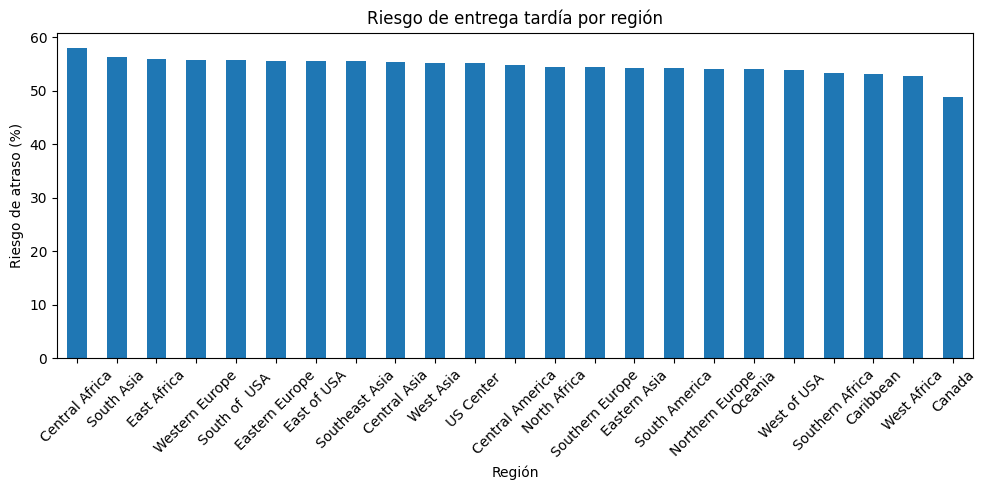

In [16]:
import matplotlib.pyplot as plt

riesgo_region["Riesgo de atraso (%)"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Riesgo de entrega tardía por región")
plt.ylabel("Riesgo de atraso (%)")
plt.xlabel("Región")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
riesgo_envio = (
    df.groupby("Shipping Mode")["Late_delivery_risk"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

riesgo_envio["mean"] *= 100

display(riesgo_envio)

,mean,count
Shipping Mode,,
First Class,95.322499,27814
Second Class,76.632781,35216
Same Day,45.743042,9737
Standard Class,38.071683,107752


Los resultados permiten observar si existen diferencias en el riesgo de entrega tardía entre regiones y modalidades de envío\. Estas variaciones pueden estar asociadas a factores operacionales, aunque en esta etapa no se puede afirmar una relación causal\.

# W1\-C · Critical comparison and questions for feedback — 30 points

Core evidence: an evidence\-based comparison of the alternatives, a provisional preference and a concrete
uncertainty on which feedback is requested\.

# W1\-D · Traceability, contributions and AI accountability — 15 points

Core evidence: identifiable sources and inspectable work, contribution evidence, and an explicit AI\-use statement\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5db68b16-0b39-495e-8ed7-dcd14b08540e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>